# Multimodal Video RAG System

This notebook implements a Retrieval-Augmented Generation (RAG) system for question-answering from videos.

## Features:
- Extract frames from videos
- Transcribe audio using Whisper
- Generate embeddings for text and images
- Store in ChromaDB vector database
- Answer questions using multimodal context

## 1. Import Required Libraries

In [1]:
import os
import cv2
import whisper
import numpy as np
from pathlib import Path
from PIL import Image
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer
import torch
from typing import List, Dict, Tuple
import json
from datetime import timedelta
import base64
from io import BytesIO

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.12.1
CUDA available: False


## 2. Configuration

In [2]:
# Configuration
VIDEO_DIR = "./downloads"
OUTPUT_DIR = "./video_processing_output"
FRAMES_DIR = os.path.join(OUTPUT_DIR, "frames")
AUDIO_DIR = os.path.join(OUTPUT_DIR, "audio")
TRANSCRIPTS_DIR = os.path.join(OUTPUT_DIR, "transcripts")
CHROMA_DB_DIR = "./chroma_db"

# Frame extraction settings
FRAME_INTERVAL = 30  # Extract 1 frame every 30 frames (1 per second at 30fps)

# Create directories
for directory in [OUTPUT_DIR, FRAMES_DIR, AUDIO_DIR, TRANSCRIPTS_DIR, CHROMA_DB_DIR]:
    os.makedirs(directory, exist_ok=True)

print(f"Video directory: {VIDEO_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"ChromaDB directory: {CHROMA_DB_DIR}")

Video directory: ./downloads
Output directory: ./video_processing_output
ChromaDB directory: ./chroma_db


## 3. Initialize Models

In [3]:
# Initialize Whisper model for audio transcription
print("Loading Whisper model...")
whisper_model = whisper.load_model("base")  # Options: tiny, base, small, medium, large
print("✓ Whisper model loaded")

# Initialize sentence transformer for text embeddings
print("Loading sentence transformer...")
text_encoder = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ Sentence transformer loaded")

# Initialize CLIP model for image embeddings
print("Loading CLIP model...")
from sentence_transformers import SentenceTransformer
clip_model = SentenceTransformer('clip-ViT-B-32')
print("✓ CLIP model loaded")

Loading Whisper model...
✓ Whisper model loaded
Loading sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Sentence transformer loaded
Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✓ CLIP model loaded


## 4. Video Processing Functions

In [4]:
def extract_frames(video_path: str, output_dir: str, interval: int = 30) -> List[str]:
    """
    Extract frames from video at specified intervals.
    
    Args:
        video_path: Path to video file
        output_dir: Directory to save frames
        interval: Extract 1 frame every N frames
    
    Returns:
        List of frame file paths
    """
    video_name = Path(video_path).stem
    frame_dir = os.path.join(output_dir, video_name)
    os.makedirs(frame_dir, exist_ok=True)
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = 0
    saved_frames = []
    
    print(f"Extracting frames from {video_name}...")
    print(f"Video FPS: {fps}")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_count % interval == 0:
            timestamp = frame_count / fps
            frame_path = os.path.join(frame_dir, f"frame_{frame_count:06d}_t{timestamp:.2f}s.jpg")
            cv2.imwrite(frame_path, frame)
            saved_frames.append(frame_path)
        
        frame_count += 1
    
    cap.release()
    print(f"✓ Extracted {len(saved_frames)} frames from {video_name}")
    return saved_frames


def transcribe_audio(video_path: str, output_dir: str) -> Dict:
    """
    Transcribe audio from video using Whisper.
    
    Args:
        video_path: Path to video file
        output_dir: Directory to save transcript
    
    Returns:
        Dictionary containing transcript and segments
    """
    video_name = Path(video_path).stem
    print(f"Transcribing audio from {video_name}...")
    
    # Transcribe using Whisper
    result = whisper_model.transcribe(video_path, verbose=False)
    
    # Save transcript
    transcript_path = os.path.join(output_dir, f"{video_name}_transcript.json")
    with open(transcript_path, 'w', encoding='utf-8') as f:
        json.dump(result, f, indent=2, ensure_ascii=False)
    
    # Save plain text version
    text_path = os.path.join(output_dir, f"{video_name}_transcript.txt")
    with open(text_path, 'w', encoding='utf-8') as f:
        f.write(result['text'])
    
    print(f"✓ Transcription complete for {video_name}")
    print(f"  Language detected: {result.get('language', 'unknown')}")
    print(f"  Segments: {len(result.get('segments', []))}")
    
    return result


def process_video(video_path: str) -> Dict:
    """
    Process a video: extract frames and transcribe audio.
    
    Args:
        video_path: Path to video file
    
    Returns:
        Dictionary with frames and transcript data
    """
    print(f"\n{'='*60}")
    print(f"Processing video: {Path(video_path).name}")
    print(f"{'='*60}")
    
    # Extract frames
    frames = extract_frames(video_path, FRAMES_DIR, FRAME_INTERVAL)
    
    # Transcribe audio
    transcript = transcribe_audio(video_path, TRANSCRIPTS_DIR)
    
    return {
        'video_path': video_path,
        'frames': frames,
        'transcript': transcript
    }

print("Video processing functions defined!")

Video processing functions defined!


## 5. Vector Database Setup

In [5]:
# Initialize ChromaDB
chroma_client = chromadb.PersistentClient(path=CHROMA_DB_DIR)

# Create or get collections
text_collection = chroma_client.get_or_create_collection(
    name="video_transcripts",
    metadata={"description": "Video transcript segments"}
)

frame_collection = chroma_client.get_or_create_collection(
    name="video_frames",
    metadata={"description": "Video frame embeddings"}
)

print("✓ ChromaDB collections initialized")
print(f"  Text collection: {text_collection.count()} documents")
print(f"  Frame collection: {frame_collection.count()} documents")

✓ ChromaDB collections initialized
  Text collection: 50 documents
  Frame collection: 440 documents


## 6. Embedding and Indexing Functions

In [6]:
def index_transcript(video_name: str, transcript: Dict):
    """
    Index transcript segments in ChromaDB.
    
    Args:
        video_name: Name of the video
        transcript: Whisper transcript result
    """
    segments = transcript.get('segments', [])
    
    if not segments:
        print(f"No segments found in transcript for {video_name}")
        return
    
    print(f"Indexing {len(segments)} transcript segments for {video_name}...")
    
    documents = []
    metadatas = []
    ids = []
    
    for i, segment in enumerate(segments):
        text = segment['text'].strip()
        if not text:
            continue
        
        documents.append(text)
        metadatas.append({
            'video_name': video_name,
            'start_time': segment['start'],
            'end_time': segment['end'],
            'segment_id': i
        })
        ids.append(f"{video_name}_seg_{i}")
    
    if documents:
        # Generate embeddings
        embeddings = text_encoder.encode(documents).tolist()
        
        # Add to collection
        text_collection.add(
            documents=documents,
            embeddings=embeddings,
            metadatas=metadatas,
            ids=ids
        )
        print(f"✓ Indexed {len(documents)} transcript segments")


def index_frames(video_name: str, frame_paths: List[str]):
    """
    Index video frames in ChromaDB using CLIP embeddings.
    
    Args:
        video_name: Name of the video
        frame_paths: List of frame file paths
    """
    print(f"Indexing {len(frame_paths)} frames for {video_name}...")
    
    documents = []
    metadatas = []
    ids = []
    images = []
    
    for frame_path in frame_paths:
        frame_name = Path(frame_path).stem
        
        # Extract timestamp from filename
        try:
            timestamp = float(frame_name.split('_t')[1].replace('s', ''))
        except:
            timestamp = 0.0
        
        # Load image
        img = Image.open(frame_path)
        images.append(img)
        
        documents.append(f"Frame from {video_name} at {timestamp:.2f}s")
        metadatas.append({
            'video_name': video_name,
            'frame_path': frame_path,
            'timestamp': timestamp
        })
        ids.append(f"{video_name}_{frame_name}")
    
    if images:
        # Generate CLIP embeddings for images
        embeddings = clip_model.encode(images).tolist()
        
        # Add to collection
        frame_collection.add(
            documents=documents,
            embeddings=embeddings,
            metadatas=metadatas,
            ids=ids
        )
        print(f"✓ Indexed {len(images)} frames")

print("Indexing functions defined!")

Indexing functions defined!


## 7. Process All Videos

In [7]:
# Find all video files in downloads directory
video_extensions = ['.mp4', '.avi', '.mov', '.mkv', '.webm']
video_files = []

if os.path.exists(VIDEO_DIR):
    for file in os.listdir(VIDEO_DIR):
        if any(file.lower().endswith(ext) for ext in video_extensions):
            video_files.append(os.path.join(VIDEO_DIR, file))

print(f"Found {len(video_files)} video(s) in {VIDEO_DIR}")
for vf in video_files:
    print(f"  - {Path(vf).name}")

# Process each video
processed_videos = []

for video_path in video_files:
    try:
        # Process video
        result = process_video(video_path)
        processed_videos.append(result)
        
        # Index in vector database
        video_name = Path(video_path).stem
        index_transcript(video_name, result['transcript'])
        index_frames(video_name, result['frames'])
        
    except Exception as e:
        print(f"Error processing {video_path}: {str(e)}")
        continue

print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"Processed {len(processed_videos)} video(s)")
print(f"{'='*60}")

Found 2 video(s) in ./downloads
  - International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage).mp4
  - Astronauts on the Space Station Celebrate the 2026 FIFA World Cup.mp4

Processing video: International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage).mp4
Extracting frames from International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)...
Video FPS: 29.97002997002997
✓ Extracted 200 frames from International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)
Transcribing audio from International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)...


/Users/anupamchakraborty/Code/my_exp/building_ai_systems_2026/MultiModal/MultiModalSearch/.venv/lib/python3.12/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Detected language: English


100%|██████████| 20022/20022 [00:04<00:00, 4448.55frames/s]


✓ Transcription complete for International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)
  Language detected: en
  Segments: 33
Indexing 33 transcript segments for International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)...
✓ Indexed 33 transcript segments
Indexing 200 frames for International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)...
✓ Indexed 200 frames

Processing video: Astronauts on the Space Station Celebrate the 2026 FIFA World Cup.mp4
Extracting frames from Astronauts on the Space Station Celebrate the 2026 FIFA World Cup...
Video FPS: 59.94005994005994
✓ Extracted 240 frames from Astronauts on the Space Station Celebrate the 2026 FIFA World Cup
Transcribing audio from Astronauts on the Space Station Celebrate the 2026 FIFA World Cup...


/Users/anupamchakraborty/Code/my_exp/building_ai_systems_2026/MultiModal/MultiModalSearch/.venv/lib/python3.12/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Detected language: English


100%|██████████| 11993/11993 [00:02<00:00, 5013.00frames/s]


✓ Transcription complete for Astronauts on the Space Station Celebrate the 2026 FIFA World Cup
  Language detected: en
  Segments: 17
Indexing 17 transcript segments for Astronauts on the Space Station Celebrate the 2026 FIFA World Cup...
✓ Indexed 17 transcript segments
Indexing 240 frames for Astronauts on the Space Station Celebrate the 2026 FIFA World Cup...
✓ Indexed 240 frames

Processing complete!
Processed 2 video(s)


## 8. Question Answering Functions

In [8]:
def search_transcripts(query: str, n_results: int = 5) -> Dict:
    """
    Search transcript segments using semantic similarity.
    
    Args:
        query: Search query
        n_results: Number of results to return
    
    Returns:
        Dictionary with search results
    """
    # Generate query embedding
    query_embedding = text_encoder.encode([query]).tolist()
    
    # Search in collection
    results = text_collection.query(
        query_embeddings=query_embedding,
        n_results=n_results
    )
    
    return results


def search_frames(query: str, n_results: int = 5) -> Dict:
    """
    Search video frames using CLIP embeddings.
    
    Args:
        query: Search query (text description of visual content)
        n_results: Number of results to return
    
    Returns:
        Dictionary with search results
    """
    # Generate query embedding using CLIP
    query_embedding = clip_model.encode([query]).tolist()
    
    # Search in collection
    results = frame_collection.query(
        query_embeddings=query_embedding,
        n_results=n_results
    )
    
    return results


def format_time(seconds: float) -> str:
    """Format seconds to MM:SS format."""
    return str(timedelta(seconds=int(seconds)))


def answer_question(question: str, n_results: int = 5):
    """
    Answer a question using multimodal RAG.
    
    Args:
        question: User's question
        n_results: Number of results to retrieve
    """
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}\n")
    
    # Search transcripts
    print("🔍 Searching transcripts...")
    transcript_results = search_transcripts(question, n_results)
    
    if transcript_results['documents'][0]:
        print(f"\n📝 Relevant Transcript Segments:\n")
        for i, (doc, metadata, distance) in enumerate(zip(
            transcript_results['documents'][0],
            transcript_results['metadatas'][0],
            transcript_results['distances'][0]
        )):
            print(f"{i+1}. [{metadata['video_name']}] at {format_time(metadata['start_time'])}")
            print(f"   Similarity: {1 - distance:.3f}")
            print(f"   Text: {doc}")
            print()
    
    # Search frames
    print("🔍 Searching video frames...")
    frame_results = search_frames(question, n_results)
    
    if frame_results['documents'][0]:
        print(f"\n🖼️  Relevant Video Frames:\n")
        for i, (doc, metadata, distance) in enumerate(zip(
            frame_results['documents'][0],
            frame_results['metadatas'][0],
            frame_results['distances'][0]
        )):
            print(f"{i+1}. [{metadata['video_name']}] at {format_time(metadata['timestamp'])}")
            print(f"   Similarity: {1 - distance:.3f}")
            print(f"   Frame: {metadata['frame_path']}")
            print()
    
    return {
        'transcript_results': transcript_results,
        'frame_results': frame_results
    }

print("Question answering functions defined!")

Question answering functions defined!


## 9. Interactive Question Answering

In [14]:
# Example questions - modify these or add your own!
example_questions = [
    #"What is the main topic discussed in the video?",
    #"What are the key points mentioned?",
    #"Can you summarize what was said?",
    "How far is ISS from Earth?",
    "What research is carried out in ISS?",
    "How ISS research is used in FIFA World Cup 2026?"
]

print("Example questions:")
for i, q in enumerate(example_questions, 1):
    print(f"{i}. {q}")

print("\nYou can now ask questions about the videos!")
print("Use the answer_question() function below.")

Example questions:
1. How far is ISS from Earth?
2. What research is carried out in ISS?
3. How ISS research is used in FIFA World Cup 2026?

You can now ask questions about the videos!
Use the answer_question() function below.


In [21]:
# Ask a question - modify the question below
#question = "On behalf of the Expedition 74 crew coming to you from 250 miles above Earth"
question = "from 250 miles above Earth"
results = answer_question(question, n_results=3)


Question: from 250 miles above Earth

🔍 Searching transcripts...

📝 Relevant Transcript Segments:

1. [International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)] at 0:02:13
   Similarity: 0.009
   Text: From our vantage point more than 200 miles above Earth, we are not just spectators.

2. [Astronauts on the Space Station Celebrate the 2026 FIFA World Cup] at 0:00:12
   Similarity: -0.007
   Text: to you from 250 miles above Earth, we are excited to celebrate the FIFA World Cup with

3. [International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)] at 0:02:55
   Similarity: -0.295
   Text: And as we soar through space at 17,500 miles per hour, each moment is a step closer to unlocking

🔍 Searching video frames...

🖼️  Relevant Video Frames:

1. [Astronauts on the Space Station Celebrate the 2026 FIFA World Cup] at 0:00:14
   Similarity: -141.242
   Frame: ./video_processing_output/frames/Astronauts on the Space Station Celebrate the 2026 FIFA Wor

## 10. Display Frame Images

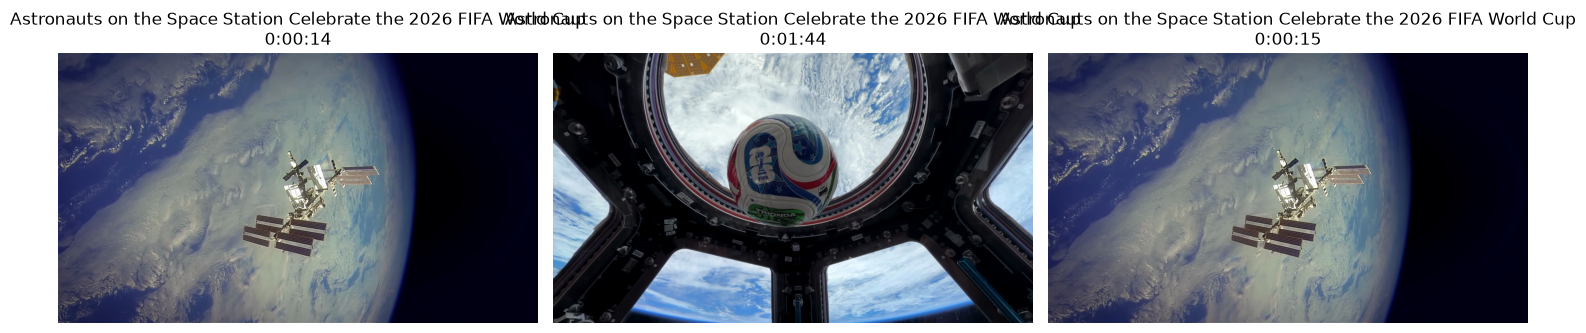

In [22]:
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt

def display_frames(frame_results: Dict, max_frames: int = 3):
    """
    Display retrieved frames as images.
    
    Args:
        frame_results: Results from frame search
        max_frames: Maximum number of frames to display
    """
    if not frame_results['metadatas'][0]:
        print("No frames to display")
        return
    
    n_frames = min(len(frame_results['metadatas'][0]), max_frames)
    
    fig, axes = plt.subplots(1, n_frames, figsize=(15, 5))
    if n_frames == 1:
        axes = [axes]
    
    for i in range(n_frames):
        metadata = frame_results['metadatas'][0][i]
        frame_path = metadata['frame_path']
        
        img = Image.open(frame_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"{metadata['video_name']}\n{format_time(metadata['timestamp'])}")
    
    plt.tight_layout()
    plt.show()

# Display frames from the last query
if 'results' in locals():
    display_frames(results['frame_results'], max_frames=3)

## 11. Statistics and Summary

In [12]:
# Display statistics
print("\n" + "="*60)
print("MULTIMODAL VIDEO RAG SYSTEM - STATISTICS")
print("="*60)

print(f"\n📊 Database Statistics:")
print(f"  Total transcript segments: {text_collection.count()}")
print(f"  Total video frames: {frame_collection.count()}")
print(f"  Videos processed: {len(processed_videos)}")

print(f"\n📁 Storage Locations:")
print(f"  Frames: {FRAMES_DIR}")
print(f"  Transcripts: {TRANSCRIPTS_DIR}")
print(f"  ChromaDB: {CHROMA_DB_DIR}")

print(f"\n🎯 System Capabilities:")
print(f"  ✓ Video frame extraction and indexing")
print(f"  ✓ Audio transcription with Whisper")
print(f"  ✓ Semantic search over transcripts")
print(f"  ✓ Visual search over video frames")
print(f"  ✓ Multimodal question answering")

print("\n" + "="*60)


MULTIMODAL VIDEO RAG SYSTEM - STATISTICS

📊 Database Statistics:
  Total transcript segments: 50
  Total video frames: 440
  Videos processed: 2

📁 Storage Locations:
  Frames: ./video_processing_output/frames
  Transcripts: ./video_processing_output/transcripts
  ChromaDB: ./chroma_db

🎯 System Capabilities:
  ✓ Video frame extraction and indexing
  ✓ Audio transcription with Whisper
  ✓ Semantic search over transcripts
  ✓ Visual search over video frames
  ✓ Multimodal question answering



## 12. Advanced Query Examples


TEXT-BASED QUERY

Question: What are the main concepts explained?

🔍 Searching transcripts...

📝 Relevant Transcript Segments:

1. [International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)] at 0:01:17
   Similarity: -0.033
   Text: We're on a relentless quest for answers. Seeking to understand the intricate workings of the

2. [International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)] at 0:00:37
   Similarity: -0.297
   Text: combustion, all sorts of things that help us understand life back on Earth.

3. [International Space Station： Humanity’s Lab in Space (Narrated by Adam Savage)] at 0:03:04
   Similarity: -0.356
   Text: the mysteries of our Earth, our universe, and propelling our pioneering spirit even farther into space.

🔍 Searching video frames...

🖼️  Relevant Video Frames:

1. [Astronauts on the Space Station Celebrate the 2026 FIFA World Cup] at 0:00:08
   Similarity: -187.448
   Frame: ./video_processing_output/frames/Astronauts 

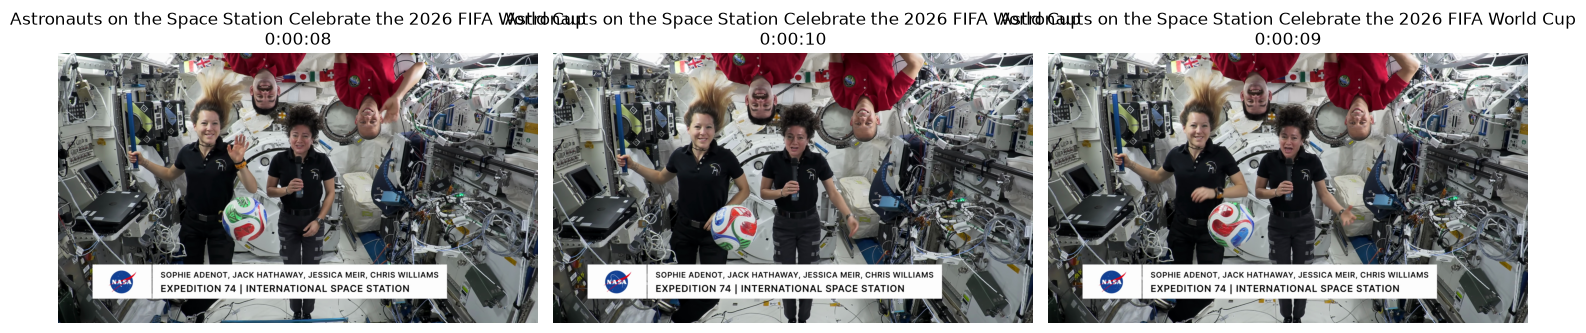

In [13]:
# Try different types of queries

# Text-based query
print("\n" + "="*60)
print("TEXT-BASED QUERY")
print("="*60)
text_results = answer_question("What are the main concepts explained?", n_results=3)

# Visual query
print("\n" + "="*60)
print("VISUAL QUERY")
print("="*60)
visual_results = answer_question("Show me scenes with people talking", n_results=3)
display_frames(visual_results['frame_results'], max_frames=3)